In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('traffic.csv', encoding='latin-1')
df.columns = df.columns.str.strip()

print("Columns: ", df.columns.tolist())
print("Shape: ", df.shape)
print(df.head())

Saving traffic.csv to traffic.csv
Columns:  ['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']
Shape:  (226278, 9)
   event        date       country      city  \
0  click  2021-08-21  Saudi Arabia    Jeddah   
1  click  2021-08-21  Saudi Arabia    Jeddah   
2  click  2021-08-21         India  Ludhiana   
3  click  2021-08-21        France   Unknown   
4  click  2021-08-21      Maldives     MalÃ©   

                              artist           album           track  \
0                             Tesher     Jalebi Baby     Jalebi Baby   
1                             Tesher     Jalebi Baby     Jalebi Baby   
2                      Reyanna Maria       So Pretty       So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores MÃ¡s  No Llores MÃ¡s   
4                             Tesher     Jalebi Baby     Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d

In [2]:
# Data Cleaning

print("MISSING VALUES")
print(df.isnull().sum())

print("\n DATA TYPES ")
print(df.dtypes)

print("\n DUPLICATES ")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Drop duplicates
df.drop_duplicates(inplace=True)

# Converting date column
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

print("\n Cleaning Done!")
print(f"Clean rows: {df.shape[0]}")

MISSING VALUES
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

 DATA TYPES 
event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

 DUPLICATES 
Duplicate rows: 103711

 Cleaning Done!
Clean rows: 122567


/tmp/ipykernel_3795/2568276896.py:16: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


In [3]:
# Summary Statistics

print(f"Total Events (Sessions):  {len(df):,}")
print(f"Unique Countries:         {df['country'].nunique()}")
print(f"Unique Cities:            {df['city'].nunique()}")
print(f"Unique Artists:           {df['artist'].nunique()}")
print(f"Unique Tracks:            {df['track'].nunique()}")
print(f"Date Range:               {df['date'].min()} to {df['date'].max()}")

print("\n TOP 5 COUNTRIES BY TRAFFIC ")
print(df['country'].value_counts().head())

print("\n TOP 5 ARTISTS BY CLICKS ")
print(df['artist'].value_counts().head())

print("\n EVENT TYPES ")
print(df['event'].value_counts())

Total Events (Sessions):  122,567
Unique Countries:         211
Unique Cities:            11993
Unique Artists:           2419
Unique Tracks:            3562
Date Range:               2021-08-19 00:00:00 to 2021-08-25 00:00:00

 TOP 5 COUNTRIES BY TRAFFIC 
country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Name: count, dtype: int64

 TOP 5 ARTISTS BY CLICKS 
artist
Tesher            8288
Anne-Marie        4029
Tundra Beats      3951
Roddy Ricch       3107
Olivia Rodrigo    3037
Name: count, dtype: int64

 EVENT TYPES 
event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


In [4]:
# Feature Engineering

# Extracting month and day
df['month'] = df['date'].dt.month_name()
df['day_of_week'] = df['date'].dt.day_name()
df['week'] = df['date'].dt.isocalendar().week

# Session count per country
df['session_count'] = df.groupby('country')['country'].transform('count')

print(" Feature Engineering Done!")
print(df[['date', 'month', 'day_of_week', 'session_count']].head())

 Feature Engineering Done!
        date   month day_of_week  session_count
0 2021-08-21  August    Saturday         7682.0
2 2021-08-21  August    Saturday        18689.0
3 2021-08-21  August    Saturday        10565.0
4 2021-08-21  August    Saturday          108.0
5 2021-08-21  August    Saturday        28664.0


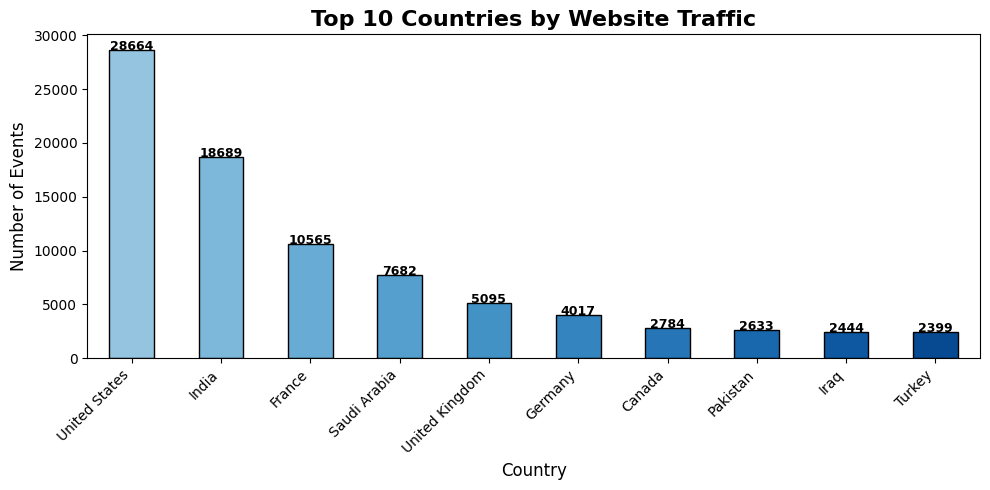

In [6]:
# Chart 1 - Bar

plt.figure(figsize=(10, 5))
top_countries = df['country'].value_counts().head(10)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
top_countries.plot(kind='bar', color=colors, edgecolor='black')

for i, v in enumerate(top_countries):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=9)

plt.title('Top 10 Countries by Website Traffic', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_top_countries.png', dpi=150)
plt.show()


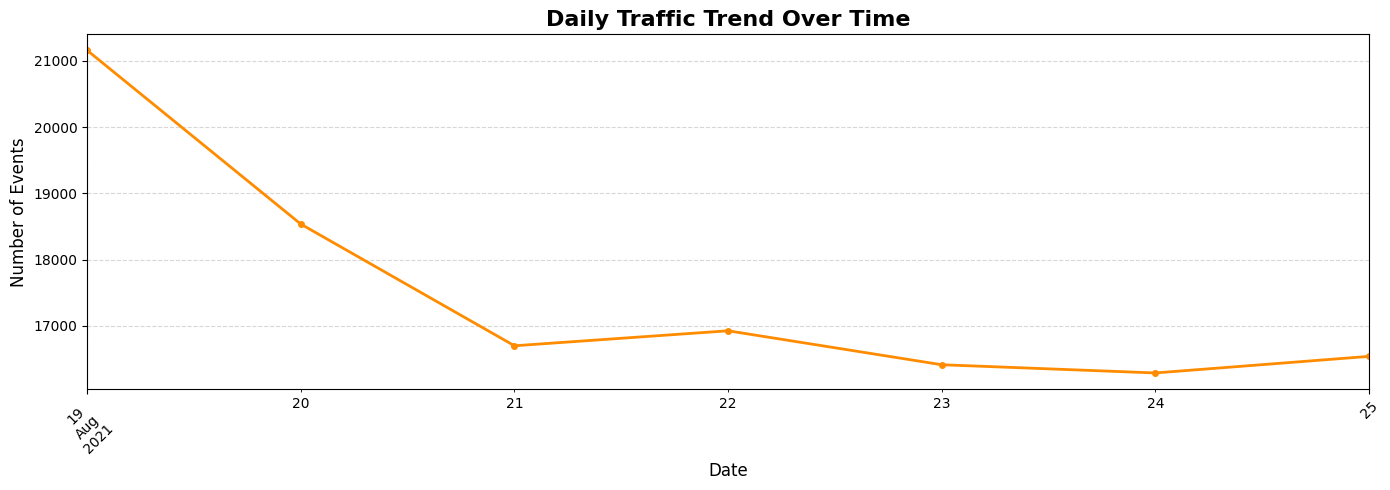

In [7]:
# Chart 2 - Line (Daily traffic trend)

plt.figure(figsize=(14, 5))
daily_traffic = df.groupby('date').size()
daily_traffic.plot(kind='line', color='darkorange', linewidth=2, marker='o', markersize=4)

plt.title('Daily Traffic Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_daily_trend.png', dpi=150)
plt.show()


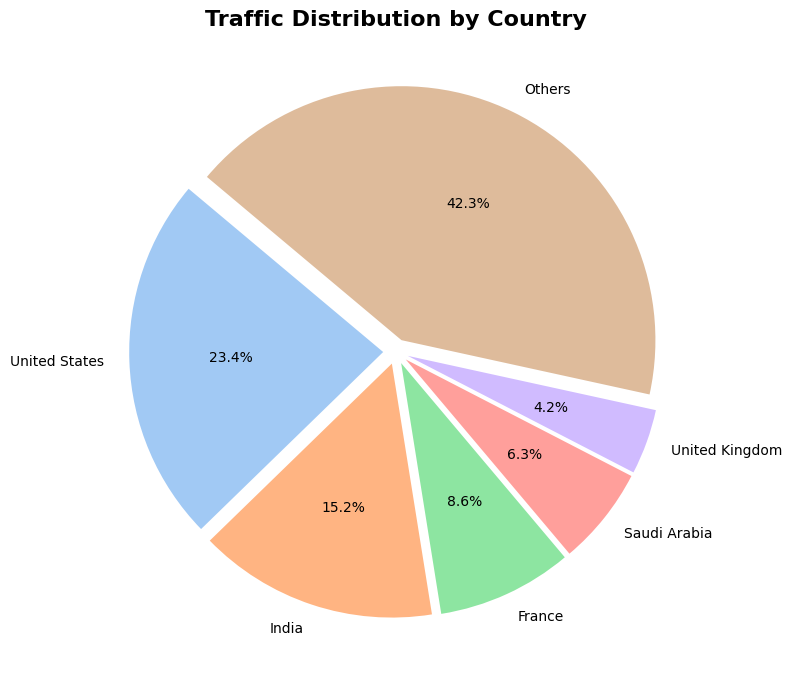

In [8]:
# Chart 3 -  Pie (Traffic by top 5 countries)

plt.figure(figsize=(8, 8))
top5 = df['country'].value_counts().head(5)
others = df['country'].value_counts()[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Others': others})])

colors = sns.color_palette('pastel')
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
        startangle=140, colors=colors,
        explode=[0.05]*len(pie_data))

plt.title('Traffic Distribution by Country', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_country_pie.png', dpi=150)
plt.show()


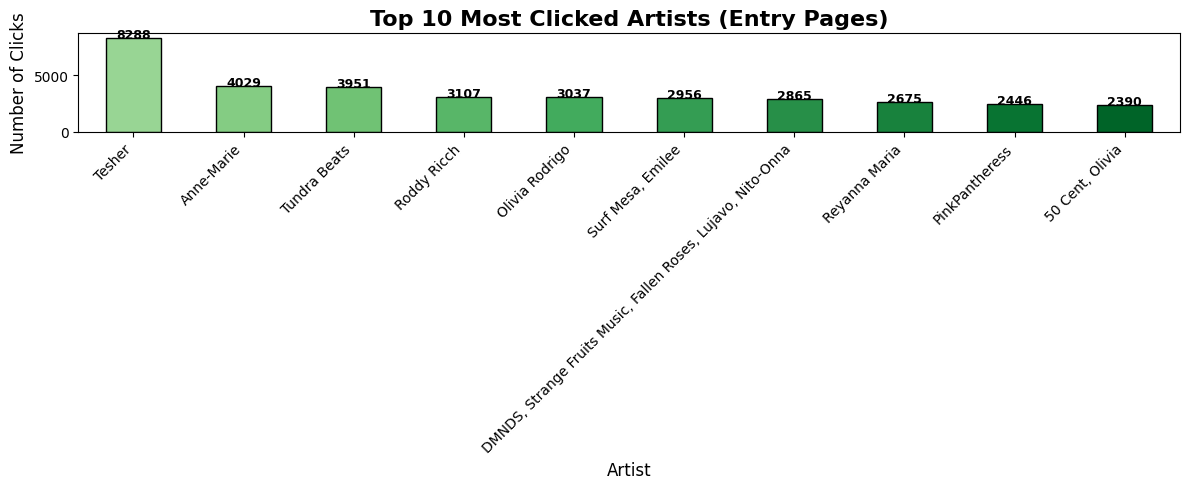

In [9]:
# Chart 4 - Top 10 Artists

plt.figure(figsize=(12, 5))
top_artists = df['artist'].value_counts().head(10)
colors = plt.cm.Greens(np.linspace(0.4, 0.9, 10))
top_artists.plot(kind='bar', color=colors, edgecolor='black')

for i, v in enumerate(top_artists):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=9)

plt.title('Top 10 Most Clicked Artists (Entry Pages)', fontsize=16, fontweight='bold')
plt.xlabel('Artist', fontsize=12)
plt.ylabel('Number of Clicks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart4_top_artists.png', dpi=150)
plt.show()


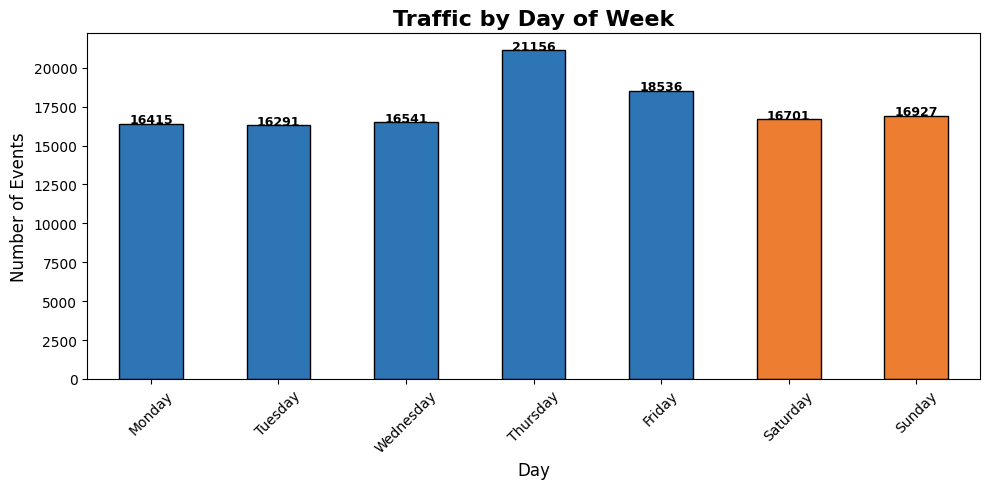

In [10]:
# Chart 5 - Traffic by day of week

plt.figure(figsize=(10, 5))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_traffic = df['day_of_week'].value_counts().reindex(day_order)
colors = ['#2E75B6' if d not in ['Saturday','Sunday']
          else '#ED7D31' for d in day_order]
day_traffic.plot(kind='bar', color=colors, edgecolor='black')

for i, v in enumerate(day_traffic):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=9)

plt.title('Traffic by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_day_traffic.png', dpi=150)
plt.show()


In [11]:
# Download all charts

from google.colab import files
files.download('chart1_top_countries.png')
files.download('chart2_daily_trend.png')
files.download('chart3_country_pie.png')
files.download('chart4_top_artists.png')
files.download('chart5_day_traffic.png')
print(" All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All charts downloaded!
